### <b>PLIP Model Testing</b>:

#### <b>Importing ARCH Dataset (Pubmed):</b>

In [6]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define path for PubMed dataset
pubmed_path = r'C:\Users\tiffa\Documents\bttai\novartis\pubmed_set\captions.json'

# Function to load JSON data into a DataFrame
def load_captions(json_path):
    with open(json_path, 'r') as file:
        data = json.load(file)
        
    # Convert to DataFrame
    df = pd.DataFrame(data)
    return df

# Load the PubMed dataset
pubmed_df = load_captions(pubmed_path)

# Transpose the DataFrame (optional)
pubmed_df_t = pubmed_df.T

# Check the DataFrame structure (optional)
pubmed_df_t.head()

# Sample image path (based on the file structure)
sample_image_path = './pubmed_set/images/' + pubmed_df_t['uuid'].iloc[0] + '.jpg'

# Read and display the sample image
img = mpimg.imread(sample_image_path)
plt.imshow(img)
plt.title(pubmed_df_t['caption'].iloc[0])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\tiffa\\Documents\\bttai\\novartis\\pubmed_set3f93c716-8fc9-42e9-bc29-bec52a51ab4b.jpg'

#### <b>Importing Model Packages:</b>

In [7]:
import torch
import numpy as np
from tqdm import tqdm
from typing import List, Union 
from PIL import Image
from torch.utils.data import DataLoader
from transformers import CLIPModel, CLIPProcessor
from datasets import Dataset, Image as DImage

#### <b>Modified Model Code:</b>

In [8]:
class PLIP:
    def __init__(self, model_name, image_paths, auth_token=None):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model_name = model_name
        self.image_paths = image_paths
        self.model, self.preprocess = self._load_model(model_name, auth_token=auth_token)
        self.model = self.model.to(self.device)
        self.image_vectors = self.encode_images(self.image_paths, batch_size=8)

    def _load_model(self, name: str, auth_token=None):
        model = CLIPModel.from_pretrained(name, use_auth_token=auth_token)
        preprocessing = CLIPProcessor.from_pretrained(name, use_auth_token=auth_token)
        return model, preprocessing

    def encode_images(self, image_paths: List[str], batch_size: int):
        def transform_fn(el):
            imgs = [Image.open(path) for path in el['image']]
            return self.preprocess(images=imgs, return_tensors='pt')

        dataset = Dataset.from_dict({'image': image_paths})
        dataset.set_format('torch')
        dataset.set_transform(transform_fn)
        dataloader = DataLoader(dataset, batch_size=batch_size)

        image_embeddings = []
        pbar = tqdm(total=len(image_paths) // batch_size, position=0)
        with torch.no_grad():
            for batch in dataloader:
                batch = {k: v.to(self.device) for k, v in batch.items()}
                image_embeddings.extend(self.model.get_image_features(**batch).detach().cpu().numpy())
                pbar.update(1)
            pbar.close()

        return np.stack(image_embeddings)

    def _cosine_similarity(self, key_vectors: np.ndarray, space_vectors: np.ndarray, normalize=True):
        if normalize:
            key_vectors = key_vectors / np.linalg.norm(key_vectors, ord=2, axis=-1, keepdims=True)
        return np.matmul(key_vectors, space_vectors.T)

    def _nearest_neighbours(self, k, key_vectors, space_vectors, normalize=True):
        cosine_sim = self._cosine_similarity(key_vectors, space_vectors, normalize=normalize)
        nn = cosine_sim.argsort()[:, -k:][:, ::-1]
        return nn

    def retrieval(self, top_k: int = 10):
        return self._nearest_neighbours(k=top_k, key_vectors=self.image_vectors, space_vectors=self.image_vectors)

#### <b>Original Test:</b>

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/Users/mohammedkhodorfirasal-tal/Documents/Professional/Work/Fellowship - Novartis/Data/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
7it [00:01,  5.58it/s]                                                                                                                                                                                

Selected Image (Index 28):


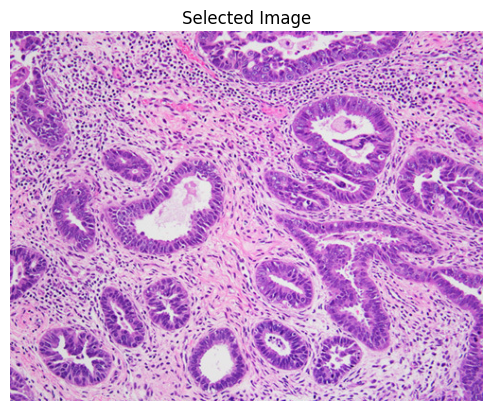

Top 5 similar images to the selected image:


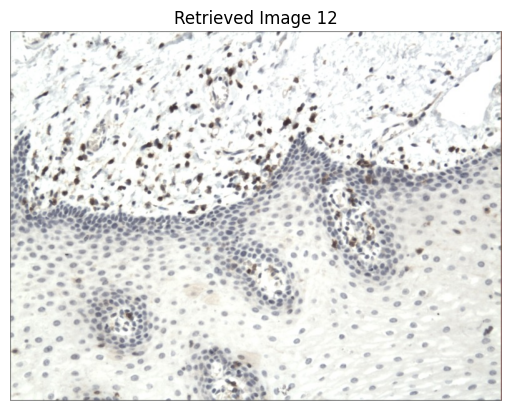

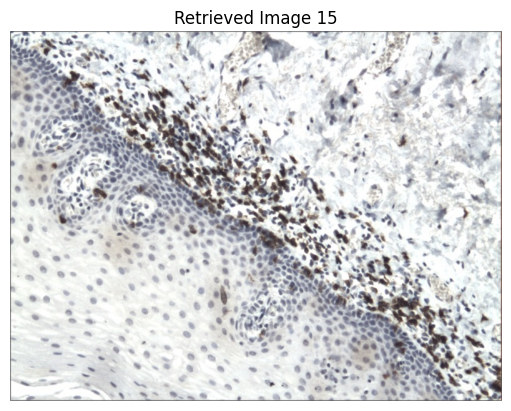

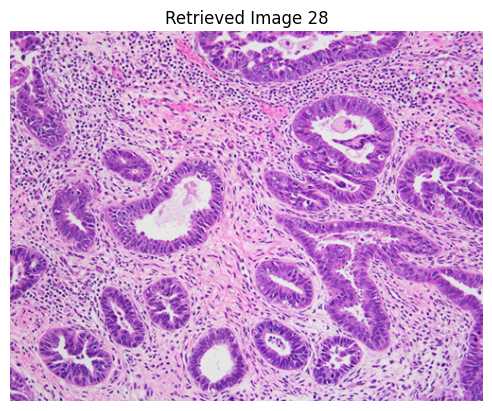

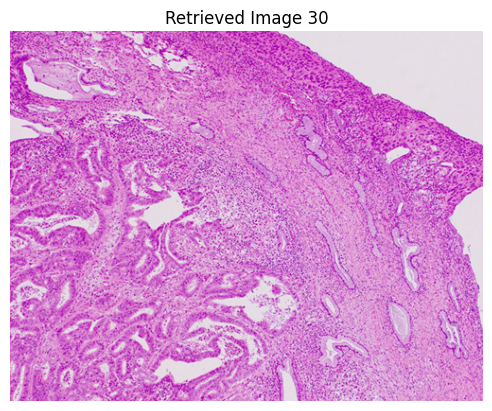

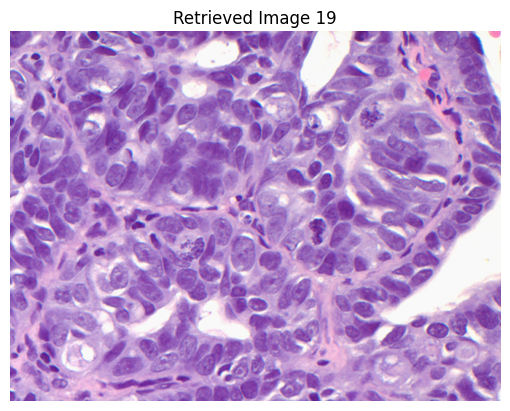

In [9]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select an image for comparison (replace 'random' with specific index if desired)
def select_image(image_paths):
    selected_image_idx = random.choice(range(len(image_paths)))  # You can manually set the index here if you want a specific image
    selected_image_path = image_paths[selected_image_idx]
    return selected_image_idx, selected_image_path

# Display the selected image
def display_image(image_path, title):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Display retrieved images
def display_retrieved_images(image_indices, image_paths):
    for idx in image_indices:
        img_path = image_paths[idx]
        display_image(img_path, f"Retrieved Image {idx + 1}")

# Load the image paths from the PubMed dataset (from your earlier work)
pubmed_image_dir = './pubmed_set/images/'
pubmed_uuids = pubmed_df_t['uuid'].tolist()
image_paths = [os.path.join(pubmed_image_dir, uuid + '.jpg') for uuid in pubmed_uuids[:50]]  # Limiting to 50 images for testing

# Initialize PLIP model for image retrieval
plip = PLIP(model_name="openai/clip-vit-base-patch32", image_paths=image_paths)

# Select an image to find similar images
selected_image_idx, selected_image_path = select_image(image_paths)

# Display the selected image
print(f"Selected Image (Index {selected_image_idx + 1}):")
display_image(selected_image_path, "Selected Image")

# Perform image retrieval for the selected image
top_k = 5  # Number of similar images to retrieve
retrieval_results = plip.retrieval(top_k=top_k)

# Get the top-k retrieved images for the selected image
retrieved_image_indices = retrieval_results[selected_image_idx]

# Display the retrieved images
print(f"Top {top_k} similar images to the selected image:")
display_retrieved_images(retrieved_image_indices, image_paths)

#### <b>Testing:</b>

7it [00:01,  6.03it/s]                                                                                                                                                                                


Selected Image (Index 17):


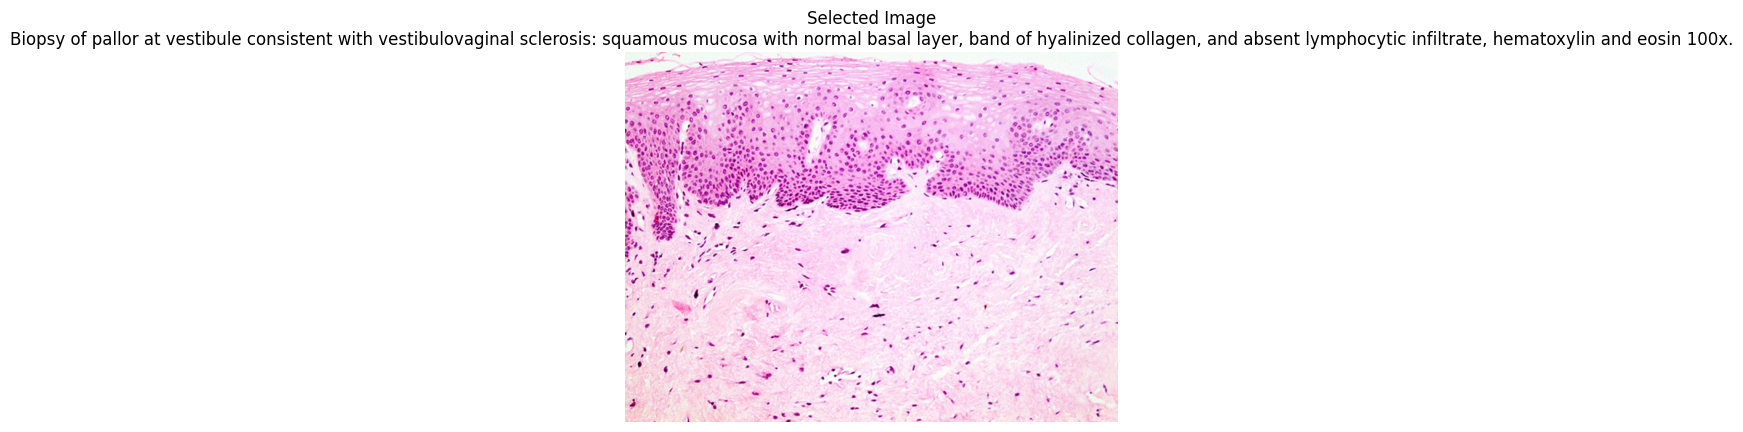

Top 5 similar images to the selected image:


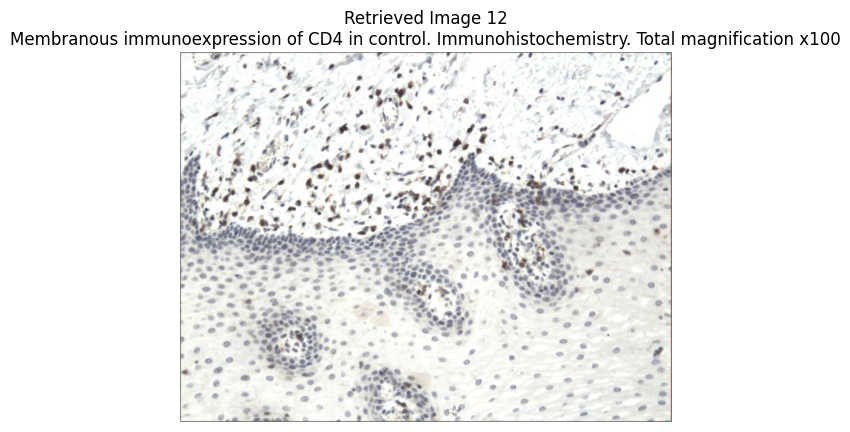

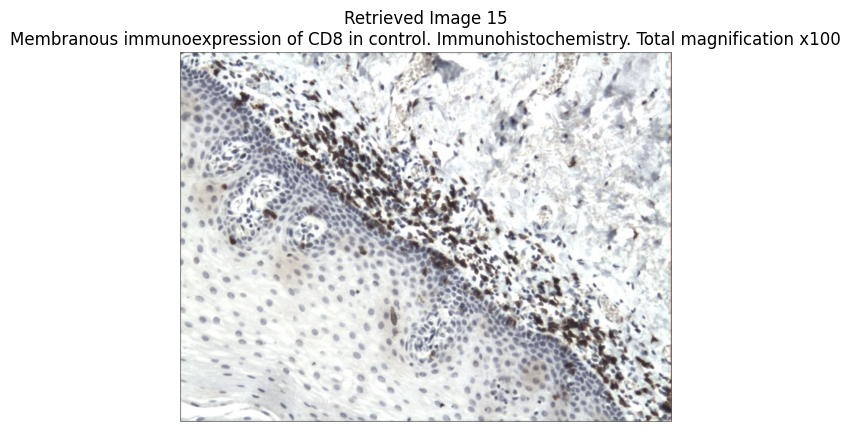

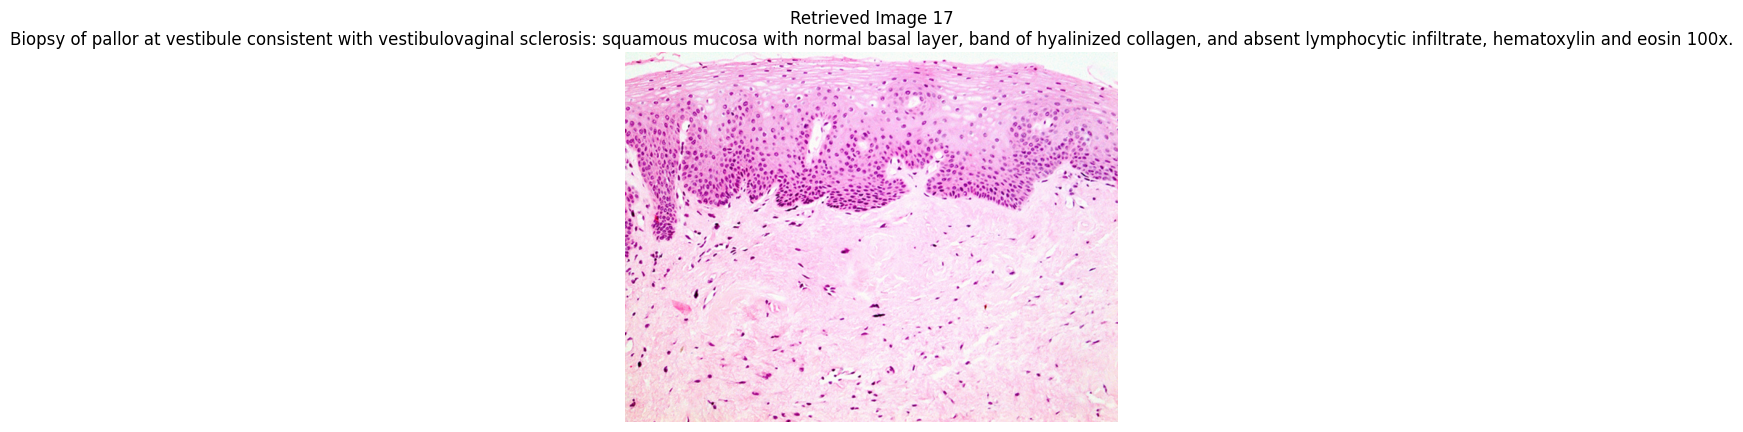

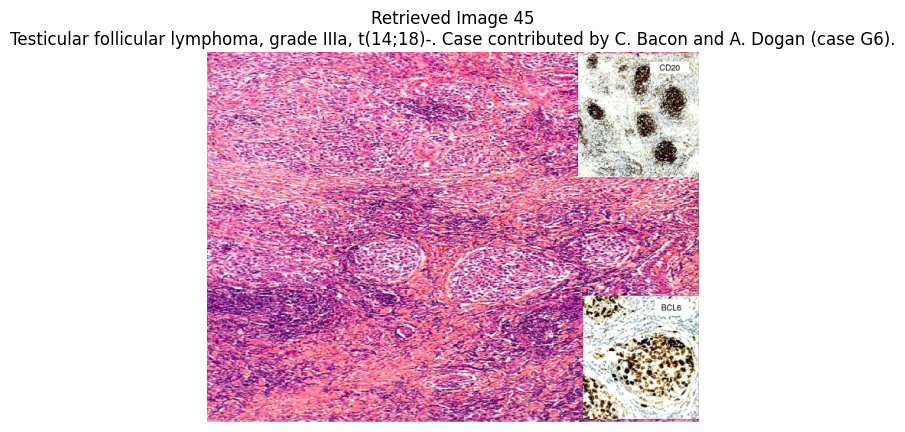

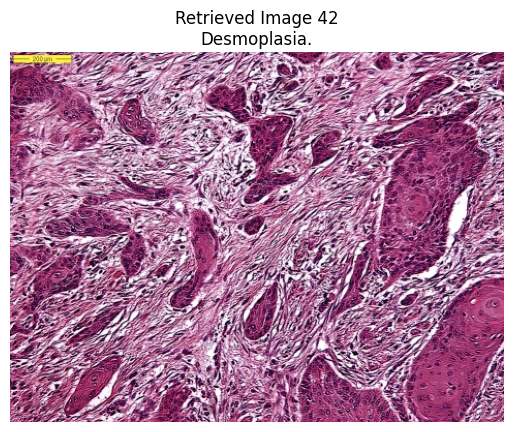

In [10]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select an image for comparison (replace 'random' with specific index if desired)
def select_image(image_paths):
    selected_image_idx = random.choice(range(len(image_paths)))  # You can manually set the index here if you want a specific image
    selected_image_path = image_paths[selected_image_idx]
    return selected_image_idx, selected_image_path

# Display the selected image and its caption
def display_image_with_caption(image_path, title, caption):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"{title}\n{caption}")
    plt.axis('off')
    plt.show()

# Display retrieved images and their captions
def display_retrieved_images_with_captions(image_indices, image_paths, captions):
    for idx in image_indices:
        img_path = image_paths[idx]
        caption = captions[idx]
        display_image_with_caption(img_path, f"Retrieved Image {idx + 1}", caption)

# Load the image paths from the PubMed dataset (from your earlier work)
pubmed_image_dir = './pubmed_set/images/'
pubmed_uuids = pubmed_df_t['uuid'].tolist()
pubmed_captions = pubmed_df_t['caption'].tolist()  # Retrieve the captions
image_paths = [os.path.join(pubmed_image_dir, uuid + '.jpg') for uuid in pubmed_uuids[:50]]  # Limiting to 50 images for testing

# Initialize PLIP model for image retrieval
plip = PLIP(model_name="openai/clip-vit-base-patch32", image_paths=image_paths)

# Select an image to find similar images
selected_image_idx, selected_image_path = select_image(image_paths)

# Display the selected image and its caption
selected_caption = pubmed_captions[selected_image_idx]
print(f"Selected Image (Index {selected_image_idx + 1}):")
display_image_with_caption(selected_image_path, "Selected Image", selected_caption)

# Perform image retrieval for the selected image
top_k = 5  # Number of similar images to retrieve
retrieval_results = plip.retrieval(top_k=top_k)

# Get the top-k retrieved images for the selected image
retrieved_image_indices = retrieval_results[selected_image_idx]

# Display the retrieved images and their captions
print(f"Top {top_k} similar images to the selected image:")
display_retrieved_images_with_captions(retrieved_image_indices, image_paths, pubmed_captions)